# **Data inspection primary with 1.3M LinkedIn Jobs & Skills (weeks 1-4)**

In this notebook, we inspect the second job-posting dataset ([asaniczka/1-3m-linkedin-jobs-and-skills-2024](https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024)) the same way as `data_inspection.ipynb`. The first dataset turned out to be a single 2-week scrape (April 2024), so this one has to answer some very concrete questions:

> Time coverage, is this another single scrape, and if so, *when*? If it is from a different month than the first dataset, the two together could give us two snapshots to compare (section 1).

> Skill labels, the first dataset only had 35 broad categories. Does `job_skills.csv` here actually contain tool-level skills like Docker or SQL (section 2)?

> Volume and scope, how many postings do our target roles get, and which countries are in it (section 1, section 2)?

> Text, is `job_summary.csv` the full posting text, and does our O*NET keyword matcher agree with the dataset's own skill lists (section 3, section 4)?

> Two snapshots, can we compare January (this dataset) against April (first dataset) for the same role (section 5)?

NOTE:

Expected layout (see `data_repo_structue.txt`): the new files live in `data/kagglev2/`. `job_summary.csv` is several GB, so we **never** load it whole, we stream it in chunks and only keep the rows we need.

### **Imports**

In [1]:
from pathlib import Path
from collections import Counter
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Kaggle**

### **Data handling**

In [ ]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

# definitions
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
DATA = ROOT / "data"
KAGGLE, KAGGLE2, ONET = DATA / "kaggle", DATA / "kagglev2", DATA / "onet"

FILES = {
    # kaggle files (this notebook)
    "v2_postings":  KAGGLE2 / "linkedin_job_postings.csv",
    "v2_skills":    KAGGLE2 / "job_skills.csv",
    "v2_summary":   KAGGLE2 / "job_summary.csv",
    # first kaggle dataset, only for the snapshot comparison
    "postings":     KAGGLE / "postings.csv",
    # O*NET for the keyword matcher
    "software_skills": ONET / "software_skills.csv",
}

In [3]:
# loop
for name, path in FILES.items():
    status = f"{path.stat().st_size/1e6:7.1f} MB" if path.exists() else "  MISSING"
    print(f"{status}  {name:20s} {path.relative_to(ROOT)}")

  415.3 MB  v2_postings          data/kagglev2/linkedin_job_postings.csv
  672.7 MB  v2_skills            data/kagglev2/job_skills.csv
 5102.0 MB  v2_summary           data/kagglev2/job_summary.csv
  516.8 MB  postings             data/kaggle/postings.csv
    3.6 MB  software_skills      data/onet/software_skills.csv


In [ ]:
# overview func
def overview(df, name):
    # one-glance summary: shape, dtypes, missingness, uniques
    print(f"── {name}: {df.shape[0]:,} rows x {df.shape[1]} cols")
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_%": (df.isna().mean() * 100).round(1),
        "n_unique": df.nunique(),
        "example": df.iloc[0] if len(df) else None,
    })

# linkedin job id from a posting url, so we can match postings across datasets
def linkedin_id(url):
    m = re.search(r"(\d{6,})/?(?:\?.*)?$", str(url))
    return int(m.group(1)) if m else np.nan

### **Section 1 | Kaggle second data set test `linkedin_job_postings.csv` the MAIN table**

One row per posting, keyed by `job_link` (the LinkedIn url), which is also the key in `job_skills.csv` and `job_summary.csv`. No description text in here, that lives in `job_summary.csv`. `search_city` / `search_country` / `search_position` are what the scraper *searched for*, not necessarily what the job is.

In [5]:
v2 = pd.read_csv(FILES["v2_postings"])
overview(v2, "v2_postings")

── v2_postings: 1,348,454 rows × 14 cols


,dtype,missing_%,n_unique,example
job_link,str,0.0,1348454,https://www.linkedin.com/jobs/view/account-executive-dispensing-norcal-north...
last_processed_time,str,0.0,722748,2024-01-21 07:12:29.00256+00
got_summary,str,0.0,2,t
got_ner,str,0.0,2,t
is_being_worked,str,0.0,2,f
job_title,str,0.0,584544,Account Executive - Dispensing (NorCal/Northern Nevada) - Becton Dickinson
company,str,0.0,90605,BD
job_location,str,0.0,29153,"San Diego, CA"
first_seen,str,0.0,6,2024-01-15
search_city,str,0.0,1018,Coronado


In [6]:
# check duplicates and other basic checks
print("duplicate job_link:", v2["job_link"].duplicated().sum())
v2["linkedin_id"] = v2["job_link"].map(linkedin_id)
print("could not parse a linkedin id:", v2["linkedin_id"].isna().sum())
for col in ["got_summary", "got_ner", "is_being_worked"]:
    if col in v2:
        print(f"{col}:", v2[col].value_counts(dropna=False).to_dict())

duplicate job_link: 0
could not parse a linkedin id: 664
got_summary: {'t': 1297877, 'f': 50577}
got_ner: {'t': 1296401, 'f': 52053}
is_being_worked: {'f': 1346978, 't': 1476}


##### **Time coverage, *the* premortem check again**

`first_seen` is when the scraper first saw the posting, so it is a scrape date, not necessarily the date the employer posted it. What we want to know: how many days/weeks does it span, and does it sit at a different time than the first dataset (Mar 24 – Apr 20, 2024)?

In [7]:
v2["first_seen_dt"] = pd.to_datetime(v2["first_seen"], errors="coerce")
s = v2["first_seen_dt"]
print(f"first_seen   min={s.min()}  max={s.max()}  missing={s.isna().sum()}")

# first dataset, only the date column, for comparison
old_dates = pd.to_datetime(pd.read_csv(FILES["postings"], usecols=["listed_time"])["listed_time"], unit="ms")
print(f"postings.csv min={old_dates.min()}  max={old_dates.max()}")

first_seen   min=2024-01-12 00:00:00  max=2024-01-17 00:00:00  missing=0
postings.csv min=2024-03-24 21:50:14  max=2024-04-20 00:26:56


Plot both datasets on the same timeline (bars, so empty days show up as gaps and not as fake lines).

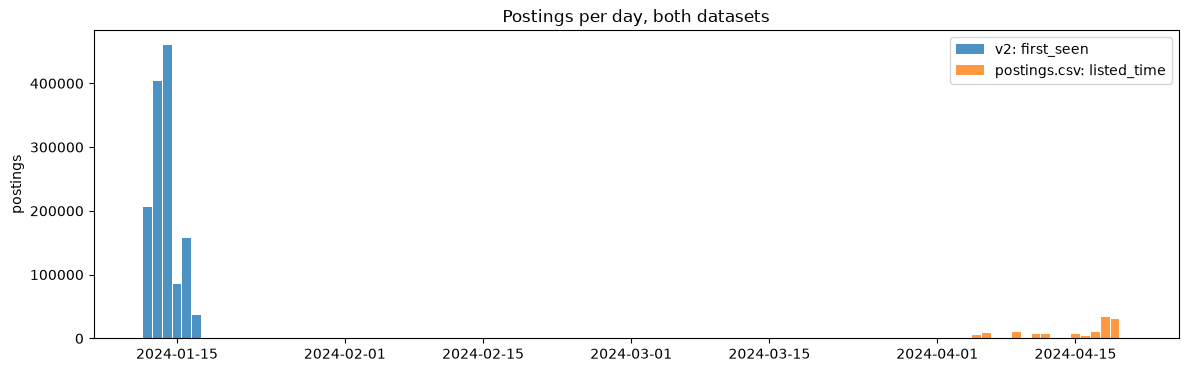

first_seen_dt
2024-01-08/2024-01-14    1070289
2024-01-15/2024-01-21     278165
Freq: W-SUN


In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
for dates, label in [(v2["first_seen_dt"], "v2: first_seen"), (old_dates, "postings.csv: listed_time")]:
    per_day = dates.dt.floor("D").value_counts().sort_index()
    ax.bar(per_day.index, per_day.values, width=0.9, label=label, alpha=0.8)
ax.set_title("Postings per day, both datasets")
ax.set_ylabel("postings")
ax.legend()
plt.show()

print(v2["first_seen_dt"].dt.to_period("W").value_counts().sort_index().to_string())

Write down here what we see.

In [9]:
# who is in the data: countries, levels, job types, what the scraper searched for
for col in ["search_country", "job_level", "job_type"]:
    if col in v2:
        display(v2[col].value_counts(dropna=False).to_frame(col))
display(v2["search_position"].value_counts().head(20))

,search_country
search_country,
United States,1149342
United Kingdom,113421
Canada,55972
Australia,29719


,job_level
job_level,
Mid senior,1204445
Associate,144009


,job_type
job_type,
Onsite,1337633
Hybrid,6562
Remote,4259


search_position
Account Executive                   19468
Christian Science Nurse             16048
Consultant Education                12138
Change Person                       12025
Circulation-Sales Representative    10978
Accountant                           9571
Chef                                 9559
Agricultural-Research Engineer       9549
Extra                                9338
Car Inspector                        9230
Dermatologist                        9031
Assembler                            8738
Bakery Supervisor                    8500
Guide                                8415
Director Social                      8319
Nurse Practitioner                   8287
Anesthesiologist                     8229
Driver                               8170
Architect                            8041
Manager Benefits                     7966
Name: count, dtype: int64

In [10]:
# type of jobs that dominate the data with top titles
v2["job_title"].str.lower().value_counts().head(20)

job_title
customer service representative                        9436
lead sales associate-ft                                7325
shift manager                                          5849
store manager                                          5748
assistant manager                                      5540
first year tax professional                            5356
lead sales associate-pt                                4924
registered nurse                                       4336
hourly supervisor & training                           2955
travel allied health professional - ct technologist    2933
host                                                   2924
account executive                                      2638
senior accountant                                      2562
restaurant manager                                     2346
hourly supervisor and training                         2230
veterinarian                                           2201
assistant general manager     

In [11]:
# how many postings would a student-relevant role actually give us? (same patterns as notebook 1)
ROLE_PATTERNS = {
    "data scientist":    r"data scien",
    "data analyst":      r"data analy",
    "software engineer": r"software (?:engineer|developer)",
    "ml engineer":       r"(?:machine learning|ml) engineer",
    "ux designer":       r"(?:ux|ui|user experience).*design",
}

def tag_role(titles):
    # first matching role per title, NaN if none
    role = pd.Series(np.nan, index=titles.index, dtype="object")
    for r, p in ROLE_PATTERNS.items():
        hit = role.isna() & titles.str.contains(p, case=False, regex=True, na=False)
        role[hit] = r
    return role

v2["role"] = tag_role(v2["job_title"])
pd.crosstab(v2["role"], v2["search_country"], margins=True)

search_country,Australia,Canada,United Kingdom,United States,All
role,,,,,
data analyst,55,157,174,1797,2183
data scientist,20,46,90,951,1107
ml engineer,10,16,7,501,534
software engineer,179,407,721,9782,11089
ux designer,22,47,80,700,849
All,286,673,1072,13731,15762


### **Section 2 | Kaggle `job_skills.csv`, finally tool-level skills?**

One row per posting, `job_skills` is a single comma-separated string. The Kaggle page says the postings were *augmented* with skills, it does not say how (probably automatic extraction, so this is **not** ground truth). Things to check: are they tool-level (Python, Docker) or soft/generic ("communication"), how messy are the spellings, and how many postings have them.

In [12]:
skills = pd.read_csv(FILES["v2_skills"])
display(overview(skills, "v2_skills"))
print("postings with a skill list:", f"{v2['job_link'].isin(skills['job_link']).mean():.1%}")
print("skill rows without a posting:", (~skills["job_link"].isin(v2["job_link"])).sum())

skills["skill_list"] = skills["job_skills"].fillna("").str.split(r",\s*").map(
    lambda xs: [x.strip().lower() for x in xs if x.strip()])
skills["n_skills"] = skills["skill_list"].map(len)
skills["n_skills"].describe().round(1)

── v2_skills: 1,296,381 rows × 2 cols


,dtype,missing_%,n_unique,example
job_link,str,0.0,1296381,https://www.linkedin.com/jobs/view/housekeeper-i-pt-at-jacksonville-state-un...
job_skills,str,0.2,1287101,"Building Custodial Services, Cleaning, Janitorial Services, Materials Handli..."


postings with a skill list: 96.1%
skill rows without a posting: 0


count    1296381.0
mean          20.8
std           11.7
min            0.0
25%           13.0
50%           19.0
75%           25.0
max          463.0
Name: n_skills, dtype: float64

In [13]:
# all skills in one Counter (faster and lighter than exploding 1M+ rows)
skill_counts = Counter(sk for lst in skills["skill_list"] for sk in lst)
print(f"distinct skill strings: {len(skill_counts):,}")
print(f"used only once: {sum(1 for c in skill_counts.values() if c == 1):,}")
pd.Series(dict(skill_counts.most_common(40)), name="n_postings")

distinct skill strings: 2,773,202
used only once: 1,951,214


communication             370143
customer service          278102
teamwork                  227609
communication skills      195949
leadership                185187
problem solving           149032
time management           142911
attention to detail       133975
problemsolving            129329
project management        121563
interpersonal skills      100267
patient care               99926
sales                      93031
nursing                    88015
collaboration              87116
training                   83656
data analysis              81964
microsoft office suite     75531
organizational skills      75274
inventory management       71911
high school diploma        67267
scheduling                 64461
bachelor's degree          63490
multitasking               62044
analytical skills          60768
microsoft office           60604
adaptability               59121
flexibility                56896
critical thinking          53081
documentation              51875
organizati

In [14]:
# how messy is it? all spellings that contain a few tools we care about
for word in ["python", "sql", "docker", "aws", "power bi"]:
    variants = {k: v for k, v in skill_counts.items() if word in k}
    top = sorted(variants.items(), key=lambda kv: -kv[1])[:8]
    print(f"{word:9s} {len(variants):5,} variants · top: {top}")

python    1,580 variants · top: [('python', 25168), ('python scripting', 244), ('python programming', 232), ('python (programming language)', 82), ('python3', 64), ('scripting languages (powershell go python)', 46), ('programming languages: c/c++ java javascript python', 40), ('5+ years of experience in java scala python go or node.js', 37)]
sql       2,981 variants · top: [('sql', 22035), ('nosql', 3237), ('sql server', 2825), ('mysql', 2331), ('postgresql', 1614), ('nosql databases', 1009), ('pl/sql', 877), ('microsoft sql server', 799)]
docker      271 variants · top: [('docker', 6254), ('docker containers', 76), ('docker swarm', 33), ('dockers', 21), ('containerization technologies (docker kubernetes)', 17), ('dockerization', 17), ('containerization (docker kubernetes)', 14), ('container orchestration (docker kubernetes)', 12)]
aws       8,292 variants · top: [('aws', 12738), ('labor laws', 1394), ('tax laws', 1228), ('laws', 679), ('aws certified solutions architect', 547), ('empl

This is the output we actually want for the tool, the share of postings per skill *for one role*:

In [15]:
role_skills = v2[["job_link", "role", "search_country"]].merge(skills[["job_link", "skill_list"]], on="job_link")

def skill_share(df, role, top=25):
    sub = df[df["role"] == role]
    counts = Counter(sk for lst in sub["skill_list"] for sk in set(lst))
    return (pd.Series(counts) / len(sub) * 100).sort_values(ascending=False).head(top).round(1).rename(
        f"% of {len(sub):,} '{role}' postings")

skill_share(role_skills, "data scientist")

python                         78.8
machine learning               70.2
data science                   68.5
sql                            55.8
r                              46.1
data visualization             36.8
statistics                     34.9
data analysis                  30.5
communication                  25.5
data mining                    21.4
spark                          21.0
tableau                        21.0
computer science               18.2
aws                            17.4
artificial intelligence        17.1
data analytics                 15.9
tensorflow                     15.8
statistical analysis           14.7
mathematics                    14.5
deep learning                  14.4
hadoop                         14.2
pytorch                        13.8
collaboration                  13.0
natural language processing    12.8
statistical modeling           12.7
Name: % of 1,027 'data scientist' postings, dtype: float64

### **Section 3 | `job_summary.csv` the text**

The biggest file. We stream it in chunks: count rows and text lengths for everything, but only keep the full text for postings in our target roles (that is what sections 4 and 5 need).

In [16]:
role_links = set(v2.loc[v2["role"].notna(), "job_link"])
all_links = set(v2["job_link"])
n_rows, n_matched, lengths, kept, random_pool = 0, 0, [], [], []

# loop over chunks
for i, chunk in enumerate(pd.read_csv(FILES["v2_summary"], chunksize=100_000)):
    n_rows += len(chunk)
    n_matched += chunk["job_link"].isin(all_links).sum()
    lengths.append(chunk["job_summary"].str.len().to_numpy())
    kept.append(chunk[chunk["job_link"].isin(role_links)])                   # full text, target roles
    random_pool.append(chunk.sample(min(300, len(chunk)), random_state=i))   # random text, ALL roles

lengths = np.concatenate(lengths)
summaries = pd.concat(kept, ignore_index=True)
random_summaries = pd.concat(random_pool, ignore_index=True)
print(f"summary rows: {n_rows:,} · match a posting: {n_matched:,} ({n_matched / len(v2):.1%} of postings have text)")
print(f"kept for target roles: {len(summaries):,} · random sample of all roles: {len(random_summaries):,}")
pd.Series(lengths).describe().round(0)

summary rows: 1,297,332 · match a posting: 1,297,332 (96.2% of postings have text)
kept for target roles: 15,113 · random sample of all roles: 3,900


count    1297332.0
mean        3819.0
std         2303.0
min           21.0
25%         2211.0
50%         3382.0
75%         4927.0
max        23748.0
dtype: float64

In [17]:
# is it the full posting or a short summary? read one
print(summaries["job_summary"].iloc[0][:1500])

Company Description
Jobs for Humanity is partnering with Capital One to build an inclusive and just employment ecosystem. Therefore, we prioritize individuals coming from the following communities: Refugee, Neurodivergent, Single Parent, Blind or Low Vision, Deaf or Hard of Hearing, Black, Hispanic, Asian, Military Veterans, the Elderly, the LGBTQ, and Justice Impacted individuals. This position is open to candidates who reside in and have the legal right to work in the country where the job is located.
Company Name: Capital One
Job Description
Locations: VA - McLean, United States of America, McLean, Virginia
Lead Machine Learning Engineer
Lead Machine Learning Engineer
As a Capital One Machine Learning Engineer (MLE), you'll be part of an Agile team dedicated to productionizing machine learning applications and systems at scale. You’ll participate in the detailed technical design, development, and implementation of machine learning applications using existing and emerging technology 

# **O*NET**

### **Section 4 | O*NET keyword matcher vs the dataset's own skills**

Same matcher as in `data_inspection.ipynb` (hot / in-demand O*NET tools only). We run it twice on the same postings:

1. on the **text** (`job_summary`), this is our own pipeline
2. on the dataset's **skill list** (`job_skills`), this maps their messy skill strings onto the same O*NET names

If both give roughly the same % per tool, that is a good sign for both. Where they disagree, one of them is missing things, worth looking at.

In [18]:
software = pd.read_csv(FILES["software_skills"])
popularity = software["Workplace Example"].value_counts()

In [19]:
# keyword matcher (copied from data_inspection.ipynb, probe text changed to job_summary) ──
flags = software.groupby("Workplace Example")[["Hot Technology", "In Demand"]].agg(lambda s: (s == "Y").any())
important = set(flags.index[flags["Hot Technology"] | flags["In Demand"]])

KEEP = {"Rust programming language": "Rust", "ANSYS simulation software": "ANSYS", "Shell script": "Shell scripting"}
def is_generic(name: str) -> bool:
    if name in KEEP: return False
    words = re.sub(r"\s+(software|systems?|tools)$", "", name, flags=re.I).split()
    return (len(words) > 1 and all(w.islower() for w in words[1:])) or \
           (len(words) == 1 and words[0].lower() in {"tax", "payroll", "productivity", "reporting", "purchasing",
                                                     "statistical", "chatbot", "disassembler", "firewall"})
VOCAB = sorted(t for t in important if not is_generic(t))

VENDORS = ["Microsoft", "Apache", "Amazon", "Google", "Adobe", "Autodesk", "Atlassian", "Oracle", "IBM", "ESRI",
           "Intuit", "Apple", "The MathWorks", "MathWorks", "Red Hat", "Dassault Systemes", "StataCorp", "SAS"]
NO_SHORT = {"analytics", "docs", "meet", "sheets", "ads", "project", "word", "access", "edge", "teams",
            "windows", "office", "azure", "workforce now", "cloud", "database",
            "workspace", "android", "ios", "macos"}
CASE_SENSITIVE = {"C", "R", "Go", "Swift", "React", "Ruby", "Chef", "Puppet", "Slack", "Zoom", "Bootstrap",
                  "Prometheus", "Snowflake", "Google", "Facebook", "Bash", "Scala", "Rust", "Excel", "Spark",
                  "Hive", "Outlook", "Safari", "Unity", "REST Assured", "Selenium", "Postman"}

def is_abbrev(acr, words):
    for k in range(len(words), 1, -1):
        init = "".join(w[0].upper() for w in words[-k:])
        it = iter(acr.upper())
        if init[0] == acr[0] and all(c in it for c in init): return True
    return False

def aliases(name):
    out = {name, KEEP.get(name, name)}
    core = re.sub(r"\s+software$", "", name, flags=re.I)
    out.add(core)
    for v in VENDORS:
        if core.startswith(v + " ") and core[len(v) + 1:].lower() not in NO_SHORT:
            out.add(core[len(v) + 1:])
    words = core.split()
    if len(words) > 2 and re.fullmatch(r"[A-Z][A-Z0-9+#]{1,5}", words[-1]) and is_abbrev(words[-1], words[:-1]):
        out.add(words[-1])
    return out

TOKEN = re.compile(r"[A-Za-z0-9+#&]+(?:[.-][A-Za-z0-9+#&]+)*")
def tokens(text):
    return TOKEN.findall(text)

alias_to_tool = {}
for t in sorted(VOCAB, key=lambda t: popularity.get(t, 0)):
    for a in aliases(t):
        toks = tokens(a)
        if toks:
            alias_to_tool[" ".join(toks) if a in CASE_SENSITIVE else " ".join(toks).lower()] = t
MAX_N = min(max(len(k.split()) for k in alias_to_tool), 8)

def extract_aliases(text):
    if not isinstance(text, str): return set()
    toks = tokens(text); low = [w.lower() for w in toks]
    found = set()
    for n in range(1, MAX_N + 1):
        for i in range(len(toks) - n + 1):
            for g in (" ".join(low[i:i + n]), " ".join(toks[i:i + n])):
                if g in alias_to_tool: found.add(g)
    return found

# safety net on a random sample of ALL postings: print very common aliases so WE decide (no auto-drop,
# common real skills like Excel can legitimately be in >10% of postings)
probe = random_summaries["job_summary"].dropna().map(extract_aliases)
share = probe.explode().value_counts() / len(probe)
print("aliases firing in >10% of all postings (review, real skill or English word?):")
print(share[share > 0.10].round(3).to_string() if (share > 0.10).any() else "  none")

MANUAL_DROP = set()          # add aliases here that turn out to be plain English, e.g. {"Go"}
for a in MANUAL_DROP: alias_to_tool.pop(a, None)

def extract_tools(text):
    return {alias_to_tool[a] for a in extract_aliases(text) if a in alias_to_tool}

print(f"{len(VOCAB)} tools → {len(alias_to_tool)} aliases")

aliases firing in >10% of all postings (review, real skill or English word?):
  none
301 tools → 450 aliases


NOTE: the safety net only *prints* aliases that fire in more than 10% of all postings. Look at them: a real skill (Excel) stays, a plain English word goes into `MANUAL_DROP` and we rerun the cell.

In [ ]:
# run the matcher on text and on the dataset's skill list, for the same postings
both = summaries.merge(role_skills[["job_link", "role", "search_country", "skill_list"]], on="job_link", how="left")
both["tools_text"]  = both["job_summary"].map(extract_tools)
both = both.merge(skills[["job_link", "job_skills"]], on="job_link", how="left")
both["tools_label"] = both["job_skills"].map(lambda s: extract_tools(s.replace(",", " ;")) if isinstance(s, str) else set())

print(f"≥1 tool from text:  {(both['tools_text'].map(len) > 0).mean():.1%}")
print(f"≥1 tool from label: {(both['tools_label'].map(len) > 0).mean():.1%}")

≥1 tool from text:  90.5%
≥1 tool from label: 89.6%


In [21]:
def tool_share(df, col, role):
    sub = df[df["role"] == role]
    return pd.Series(Counter(t for s in sub[col] for t in s), dtype=float) / max(len(sub), 1) * 100

ROLE = "data scientist"
compare = pd.DataFrame({
    "% from text":  tool_share(both, "tools_text", ROLE),
    "% from label": tool_share(both, "tools_label", ROLE),
}).fillna(0).round(1)
compare["diff"] = (compare["% from text"] - compare["% from label"]).round(1)
compare.sort_values("% from text", ascending=False).head(25)

,% from text,% from label,diff
Python,79.0,81.1,-2.1
Structured query language SQL,55.1,58.1,-3.0
R,49.7,0.0,49.7
Amazon Web Services AWS software,24.5,23.2,1.3
Apache Spark,21.2,2.0,19.2
Tableau,21.0,21.9,-0.9
TensorFlow,16.6,16.3,0.3
Oracle Java,13.4,13.6,-0.2
PyTorch,13.3,14.2,-0.9
Apache Hadoop,11.1,15.6,-4.5


> **Things to note:** big positive `diff` = our text matcher finds the tool but the dataset's labels miss it (or our matcher has a false positive, check a posting!). Big negative `diff` = the labels have it but the text does not say it literally, that is where synonym matching (weeks 6-8) could help.

### **Section 5 | Two snapshots? January vs April (`postings.csv`)**

If section 1 shows the two datasets were scraped at different times, this is the cheapest possible trend: the same role, the same matcher, two points in time. We use US postings only (the first dataset is US) and drop postings that appear in **both** datasets (same LinkedIn id).

> Big caveat for the report: two different scrapers with different search strategies. A difference can be the scraper, not the market. So we treat this as a *first test* of a trend definition, not as a finding yet.

In [22]:
old = pd.read_csv(FILES["postings"], usecols=["job_id", "title", "description", "listed_time"])
old["role"] = tag_role(old["title"])
old = old[old["role"].notna()].copy()

# overlap between the datasets (same linkedin posting)
overlap = set(old["job_id"]) & set(v2["linkedin_id"].dropna().astype(int))
print(f"postings in both datasets: {len(overlap):,}")

new = both[both["search_country"].eq("United States")].copy()
new = new[~new["job_link"].map(linkedin_id).isin(overlap)]
old = old[~old["job_id"].isin(overlap)]
old["tools_text"] = old["description"].map(extract_tools)

print(pd.DataFrame({"jan (v2, US)": new["role"].value_counts(), "apr (postings.csv)": old["role"].value_counts()}))

postings in both datasets: 0
                   jan (v2, US)  apr (postings.csv)
role                                               
software engineer          9356                1573
data analyst               1752                 463
data scientist              884                 351
ux designer                 689                 161
ml engineer                 457                  99


In [23]:
# share per tool in jan vs apr + a two-proportion z-test as a first testable "trend" definition
def snapshot_compare(role, top=20):
    a, b = new[new["role"] == role], old[old["role"] == role]
    pa, pb = tool_share(a, "tools_text", role) / 100, tool_share(b, "tools_text", role) / 100
    df = pd.DataFrame({"jan_%": pa, "apr_%": pb}).fillna(0).astype(float)
    p = (df["jan_%"] * len(a) + df["apr_%"] * len(b)) / (len(a) + len(b))
    se = np.sqrt(p * (1 - p) * (1 / len(a) + 1 / len(b)))
    df["change_pp"] = (df["apr_%"] - df["jan_%"]) * 100
    df["z"] = (df["apr_%"] - df["jan_%"]) / se.replace(0, np.nan)
    df["signal"] = np.where(df["z"] > 1.96, "↑", np.where(df["z"] < -1.96, "↓", "–"))
    df[["jan_%", "apr_%"]] *= 100
    print(f"{role}: n_jan={len(a):,}  n_apr={len(b):,}")
    return df.sort_values("apr_%", ascending=False).head(top).round(1)

snapshot_compare("data scientist")

data scientist: n_jan=884  n_apr=351


,jan_%,apr_%,change_pp,z,signal
Python,79.6,79.8,0.1,0.1,–
Structured query language SQL,57.6,55.3,-2.3,-0.7,–
R,51.4,50.7,-0.6,-0.2,–
Amazon Web Services AWS software,25.1,23.6,-1.5,-0.5,–
Apache Spark,21.7,17.7,-4.1,-1.6,–
Tableau,22.4,16.0,-6.4,-2.5,↓
SAS,9.2,15.1,5.9,3.0,↑
Scala,10.5,14.0,3.4,1.7,–
PyTorch,13.3,13.4,0.0,0.0,–
TensorFlow,16.3,11.1,-5.2,-2.3,↓


In [24]:
snapshot_compare("software engineer")

software engineer: n_jan=9,356  n_apr=1,573


,jan_%,apr_%,change_pp,z,signal
Oracle Java,45.5,40.4,-5.2,-3.8,↓
Python,43.9,38.9,-5.0,-3.7,↓
Structured query language SQL,32.9,32.7,-0.2,-0.1,–
JavaScript,27.8,29.8,2.0,1.7,–
Amazon Web Services AWS software,38.5,27.7,-10.9,-8.3,↓
C++,27.3,25.1,-2.2,-1.8,–
C#,13.0,19.4,6.4,6.8,↑
Docker,24.3,17.2,-7.1,-6.2,↓
Kubernetes,24.1,17.2,-7.0,-6.1,↓
Hypertext markup language HTML,15.3,16.5,1.1,1.1,–


> **Things to note:** how many tools get an ↑/↓ at all? If almost everything is "–", three months is too short to see much (also a finding). If *everything* moves in the same direction, that smells like a scraper difference, not a trend.

### **Findings towards decisions**


| Question | Finding | Decision / next step |
|---|---|---|
| When was v2 scraped, how many days? | Jan 12–17 2024, 6 days, 79% in the first week | Single snapshot, like dataset 1 |
| Different time from `postings.csv`? (two snapshots possible?) | Yes, about 3 months apart, with 0 overlapping postings | Technically two snapshots, but confounded by different scrapers and level mix. Use for a stability test, not trend claims |
| Postings per target role (US / all countries) | SE 9,782 / 11,089 · DA 1,797 / 2,183 · DS 951 / 1,107 · UX 700 / 849 · ML 501 / 534 | Primary dataset. US-only for comparisons with dataset 1 |
| `job_skills.csv` tool-level? how messy? | Yes: ~21 skills per posting, 96% coverage, DS top skills Python 79%, ML 70%, SQL 56%. Very messy: 2.77M variants, hyphens stripped | Use as benchmark and synonym source, not as ground truth |
| `job_summary.csv` full text? | Yes, full postings, 96% coverage, same length profile as dataset 1 | Run our matcher on this text as the main pipeline |
| Text matcher vs dataset labels agree? | Yes, within ~3 points for most DS tools (Python, SQL, AWS, Tableau, TensorFlow, PyTorch, Java). The big gaps (R, Spark, Scala, scikit-learn, Excel = 0% from labels) are **our bug**, not real disagreement: we lowercased the labels, so case-sensitive aliases like "R" never match, and the dataset writes "scikitlearn" | Fix the label-side matching (below), rerun, then report agreement |
| Jan vs Apr: how many tools with a significant change? | DS: 5 of 20, mixed directions (≈ noise). SE: 14 of 20, 13 of them down (≈ sample difference) | No trend claims. Reframe Goal 2: O*NET flags + stability test |
| Which dataset(s) do we build on? | v2 is larger with validated skills; v1 replicates the results and has entry-level postings | v2 primary, v1 for replication and entry level. Check v2's license |
